# EnterpriseIQ Customer Churn Exploratory Data Analysis

## Objectives

This notebook examines the customer churn dataset before model development.

The analysis will:

1. Validate the dataset dimensions and identifiers.
2. Inspect column types and missing values.
3. Measure target class balance.
4. Compare churn across important customer segments.
5. Identify data-quality and leakage risks.
6. Produce initial business hypotheses for model development.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "telco_customer_churn.csv"

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")

Matplotlib is building the font cache; this may take a moment.


Project root: /Users/tusharchaudhary/Projects/enterpriseiq
Dataset path: /Users/tusharchaudhary/Projects/enterpriseiq/data/raw/telco_customer_churn.csv


In [2]:
raw_df = pd.read_csv(DATA_PATH)

print(f"Rows: {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]}")
display(raw_df.head())

Rows: 7,043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
duplicate_rows = raw_df.duplicated().sum()
duplicate_customer_ids = raw_df["customerID"].duplicated().sum()
unique_customers = raw_df["customerID"].nunique()

print(f"Duplicate rows: {duplicate_rows}")
print(f"Duplicate customer IDs: {duplicate_customer_ids}")
print(f"Unique customers: {unique_customers:,}")

Duplicate rows: 0
Duplicate customer IDs: 0
Unique customers: 7,043


In [5]:
column_summary = pd.DataFrame(
    {
        "data_type": raw_df.dtypes.astype(str),
        "non_null_values": raw_df.notna().sum(),
        "unique_values": raw_df.nunique(),
    }
)

column_summary["missing_values"] = raw_df.isna().sum()
column_summary["missing_percent"] = (column_summary["missing_values"] / len(raw_df) * 100).round(2)

display(column_summary)

,data_type,non_null_values,unique_values,missing_values,missing_percent
customerID,str,7043,7043,0,0.0
gender,str,7043,2,0,0.0
SeniorCitizen,int64,7043,2,0,0.0
Partner,str,7043,2,0,0.0
Dependents,str,7043,2,0,0.0
tenure,int64,7043,73,0,0.0
PhoneService,str,7043,2,0,0.0
MultipleLines,str,7043,3,0,0.0
InternetService,str,7043,3,0,0.0
OnlineSecurity,str,7043,3,0,0.0


In [6]:
blank_strings = {}

for column in raw_df.select_dtypes(include="object").columns:
    blank_count = raw_df[column].str.strip().eq("").sum()

    if blank_count > 0:
        blank_strings[column] = int(blank_count)

print("Columns containing blank strings:")
print(blank_strings)

Columns containing blank strings:
{'TotalCharges': 11}


/var/folders/bl/7xsb31k108d_w_lwzqnvvhgr0000gn/T/ipykernel_21977/2279364401.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in raw_df.select_dtypes(include="object").columns:


In [7]:
df = raw_df.copy()

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce",
)

df["ChurnFlag"] = df["Churn"].map(
    {
        "No": 0,
        "Yes": 1,
    }
)

print(df[["TotalCharges", "Churn", "ChurnFlag"]].dtypes)
print()
print("Missing values after conversion:")
display(df.isna().sum().sort_values(ascending=False).head())

TotalCharges    float64
Churn               str
ChurnFlag         int64
dtype: object

Missing values after conversion:


TotalCharges      11
customerID         0
gender             0
Churn              0
MonthlyCharges     0
dtype: int64

In [8]:
missing_total_charges = df[df["TotalCharges"].isna()][
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "Churn",
    ]
]

display(missing_total_charges)

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,NaN,Two year,No
753,3115-CZMZD,0,20.25,NaN,Two year,No
936,5709-LVOEQ,0,80.85,NaN,Two year,No
1082,4367-NUYAO,0,25.75,NaN,Two year,No
1340,1371-DWPAZ,0,56.05,NaN,Two year,No
3331,7644-OMVMY,0,19.85,NaN,Two year,No
3826,3213-VVOLG,0,25.35,NaN,Two year,No
4380,2520-SGTTA,0,20.00,NaN,Two year,No
5218,2923-ARZLG,0,19.70,NaN,One year,No
6670,4075-WKNIU,0,73.35,NaN,Two year,No


In [9]:
churn_summary = df["Churn"].value_counts().rename_axis("churn").reset_index(name="customers")

churn_summary["percentage"] = (churn_summary["customers"] / len(df) * 100).round(2)

display(churn_summary)

,churn,customers,percentage
0,No,5174,73.46
1,Yes,1869,26.54


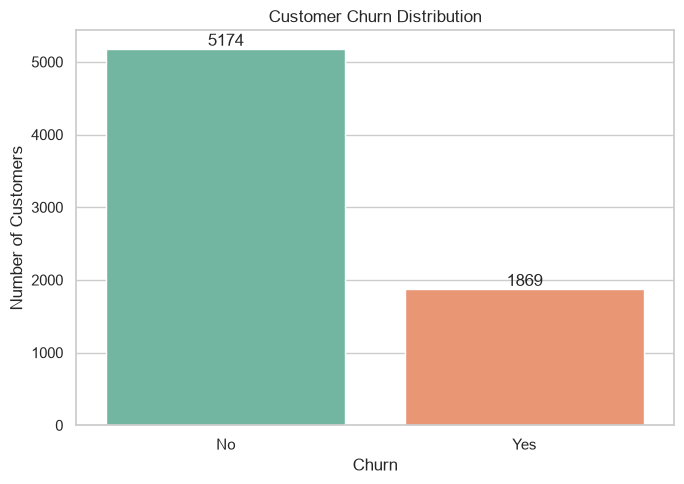

In [10]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    palette="Set2",
    legend=False,
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "churn_distribution.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [11]:
contract_summary = (
    df.groupby("Contract", observed=False)
    .agg(
        customers=("customerID", "count"),
        churn_rate=("ChurnFlag", "mean"),
    )
    .reset_index()
)

contract_summary["churn_rate_percent"] = (contract_summary["churn_rate"] * 100).round(2)

display(
    contract_summary[["Contract", "customers", "churn_rate_percent"]].sort_values(
        "churn_rate_percent", ascending=False
    )
)

,Contract,customers,churn_rate_percent
0,Month-to-month,3875,42.71
1,One year,1473,11.27
2,Two year,1695,2.83


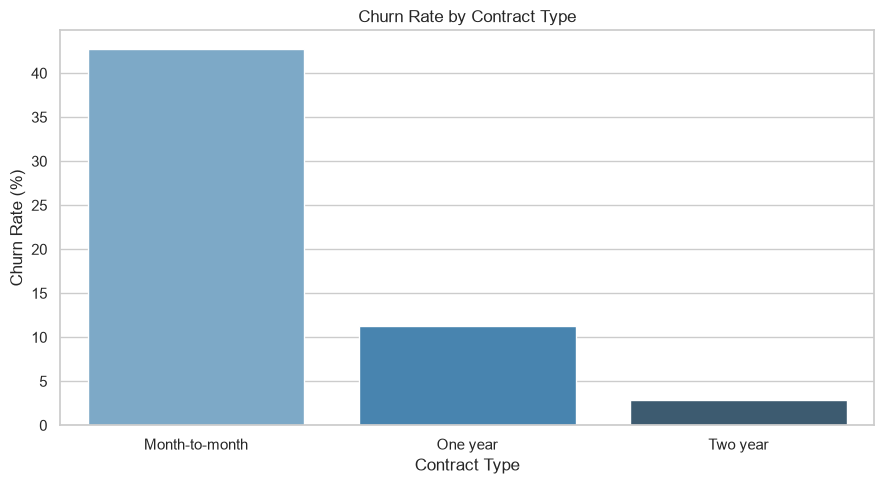

In [12]:
plt.figure(figsize=(9, 5))

contract_plot = contract_summary.sort_values(
    "churn_rate_percent",
    ascending=False,
)

sns.barplot(
    data=contract_plot,
    x="Contract",
    y="churn_rate_percent",
    hue="Contract",
    palette="Blues_d",
    legend=False,
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "churn_by_contract.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

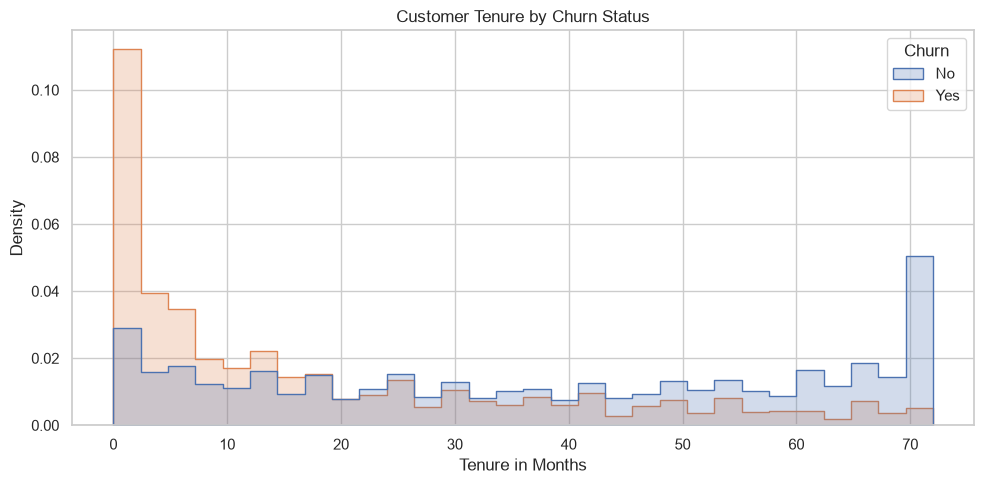

In [14]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    stat="density",
    multiple="layer",
    common_norm=False,
    element="step",
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Tenure in Months")
plt.ylabel("Density")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "tenure_by_churn.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

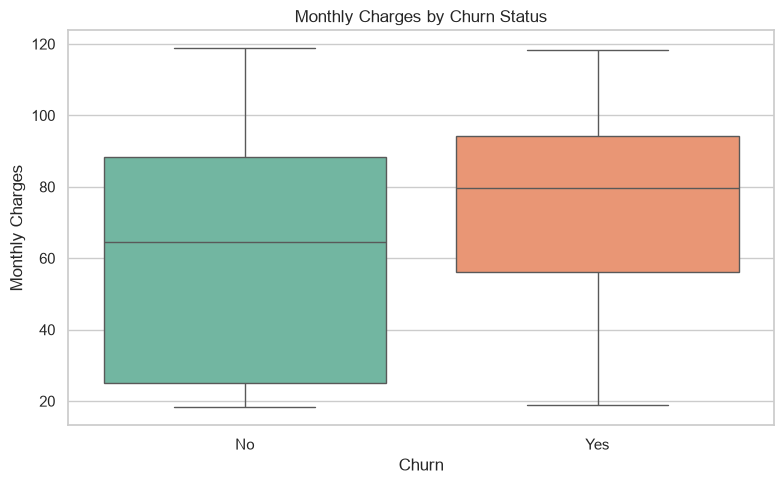

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    palette="Set2",
    legend=False,
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "monthly_charges_by_churn.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [16]:
numerical_summary = (
    df.groupby("Churn", observed=False)[["tenure", "MonthlyCharges", "TotalCharges"]]
    .agg(["mean", "median", "std"])
    .round(2)
)

display(numerical_summary)

tenure               MonthlyCharges               TotalCharges           \
        mean median    std           mean median    std         mean   median   
Churn                                                                           
No     37.57   38.0  24.11          61.27  64.43  31.09      2555.34  1683.60   
Yes    17.98   10.0  19.53          74.44  79.65  24.67      1531.80   703.55   

                
           std  
Churn           
No     2329.46  
Yes    1890.82

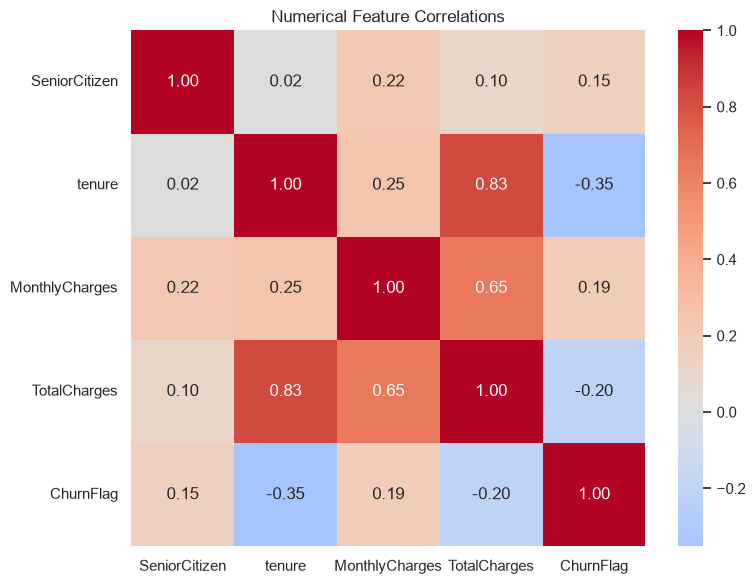

In [17]:
numeric_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ChurnFlag",
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
)

plt.title("Numerical Feature Correlations")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "correlation_heatmap.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [18]:
categorical_columns = [
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity",
    "PaperlessBilling",
]

for column in categorical_columns:
    summary = (
        df.groupby(column, observed=False)
        .agg(
            customers=("customerID", "count"),
            churn_rate=("ChurnFlag", "mean"),
        )
        .reset_index()
    )

    summary["churn_rate_percent"] = (summary["churn_rate"] * 100).round(2)

    print(f"\nChurn analysis for: {column}")

    display(
        summary[[column, "customers", "churn_rate_percent"]].sort_values(
            "churn_rate_percent", ascending=False
        )
    )


Churn analysis for: InternetService


,InternetService,customers,churn_rate_percent
1,Fiber optic,3096,41.89
0,DSL,2421,18.96
2,No,1526,7.40



Churn analysis for: PaymentMethod


,PaymentMethod,customers,churn_rate_percent
2,Electronic check,2365,45.29
3,Mailed check,1612,19.11
0,Bank transfer (automatic),1544,16.71
1,Credit card (automatic),1522,15.24



Churn analysis for: TechSupport


,TechSupport,customers,churn_rate_percent
0,No,3473,41.64
2,Yes,2044,15.17
1,No internet service,1526,7.40



Churn analysis for: OnlineSecurity


,OnlineSecurity,customers,churn_rate_percent
0,No,3498,41.77
2,Yes,2019,14.61
1,No internet service,1526,7.40



Churn analysis for: PaperlessBilling


,PaperlessBilling,customers,churn_rate_percent
1,Yes,4171,33.57
0,No,2872,16.33


In [19]:
identifier_columns = ["customerID"]
target_columns = ["Churn", "ChurnFlag"]

print("Exclude from model features:")
print(f"Identifiers: {identifier_columns}")
print(f"Targets: {target_columns}")

print("\nPotential data-quality concern:")
print("TotalCharges requires numeric conversion and missing-value handling.")

print("\nCategorical feature concern:")
print("SeniorCitizen is numerically stored but conceptually categorical.")

Exclude from model features:
Identifiers: ['customerID']
Targets: ['Churn', 'ChurnFlag']

Potential data-quality concern:
TotalCharges requires numeric conversion and missing-value handling.

Categorical feature concern:
SeniorCitizen is numerically stored but conceptually categorical.


In [20]:
overall_churn_rate = df["ChurnFlag"].mean() * 100

highest_risk_contract = contract_summary.loc[
    contract_summary["churn_rate"].idxmax(),
    "Contract",
]

new_customer_churn_rate = df.loc[df["tenure"] <= 12, "ChurnFlag"].mean() * 100

established_customer_churn_rate = df.loc[df["tenure"] > 12, "ChurnFlag"].mean() * 100

print(f"Overall churn rate: {overall_churn_rate:.2f}%")
print(f"Highest-risk contract type: {highest_risk_contract}")
print(f"Churn rate for customers with tenure <= 12 months: {new_customer_churn_rate:.2f}%")
print(f"Churn rate for customers with tenure > 12 months: {established_customer_churn_rate:.2f}%")
print(f"Rows with missing TotalCharges: {df['TotalCharges'].isna().sum()}")

Overall churn rate: 26.54%
Highest-risk contract type: Month-to-month
Churn rate for customers with tenure <= 12 months: 47.44%
Churn rate for customers with tenure > 12 months: 17.13%
Rows with missing TotalCharges: 11


## Initial findings

- The dataset contains 7,043 customer records and 21 original columns.
- Customer IDs are unique, and no duplicate customer rows were identified.
- The overall churn rate is approximately **[enter measured value]%**.
- `TotalCharges` contains **[enter count]** values that become missing after numeric conversion.
- The missing `TotalCharges` records appear to be associated with **[describe tenure observation]**.
- The highest-risk contract category is **[enter category]**.
- Customers with shorter tenure show **[higher/lower]** churn than established customers.
- Monthly charges are generally **[higher/lower]** among churned customers.
- `customerID` must be excluded from model features because it is an identifier.
- `Churn` is the target and cannot be included in the input features.

## Modeling implications

1. Convert `TotalCharges` into a numerical feature.
2. Handle missing values inside the preprocessing pipeline.
3. Treat `SeniorCitizen` as categorical.
4. Remove `customerID` from the feature matrix.
5. Encode categorical columns without using information from the test set.
6. Use stratified train/test splitting because the target is imbalanced.
7. Evaluate precision, recall, F1, ROC-AUC, and PR-AUC rather than accuracy alone.